In [1]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [15]:
ws = xr.open_mfdataset(
    FILEPATH + "grid_mean_wss_BARRA-R2_NEM_wind_2030_NEM_unweighted.nc"
)

In [16]:
ws

<xarray.Dataset> Size: 269kB
Dimensions:  (time: 16802)
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
    height   float64 8B ...
    crs      int32 4B ...
Data variables:
    wss      (time) float64 134kB dask.array<chunksize=(16802,), meta=np.ndarray>

### Drought definition

10th percentile, based on AEMO report for wind lulls (pg 31, Fig 41): https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf?rev=7436be91333e4603bc59158b0bf095a1&sc_lang=en&hash=A49B4BC337B25B842566B8F5EE4C8331 

In [9]:
DROUGHT_Q = 0.1

In [10]:
import xclim

INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520ecaf50>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520ed1490>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520ed3510>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520ed3690>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520efd4d0>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520efdbd0>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520efebd0>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520eff0d0>
INFO:root:Choice not found. Ignoring: malformed node or string on line 1: <ast.Name object at 0x14c520eff410>
INFO:root:

Assign units to wind speed dataset for `xclim` compatability

In [17]:
ws["wss"] = ws["wss"].assign_attrs(units="m/s")

Get drought threshold for winter (MJJ) wind

In [52]:
ws_mjj = ws["wss"].where(ws["wss"].time.dt.month.isin([5, 6, 7]), drop=True)

In [53]:
drought_thresh = ws_mjj.quantile(DROUGHT_Q, "time")
print(drought_thresh)

<xarray.DataArray 'wss' ()> Size: 8B
dask.array<getitem, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    quantile  float64 8B 0.1
Attributes:
    units:    m/s


#### `xclim` function option 1

Binary array indicating drought day or not

In [54]:
drought_days = xr.where(
    ws_mjj < drought_thresh,
    True, False
).assign_attrs(
    units="n/a"
)

Find events

In [57]:
drought_events = xclim.indices.run_length.find_events(
    drought_days,
    window=1,
    data=ws_mjj
)

Find annual max

In [59]:
# Dimension from xclim function is 'event', so need to swap to time
drought_events_new = drought_events.assign_coords(
    time=("event", drought_events["event_start"].data)
).drop_vars("event_start")

In [60]:
drought_events_new = drought_events_new.swap_dims({"event": "time"}).dropna("time")

In [62]:
drought_events_new

<xarray.Dataset> Size: 9kB
Dimensions:                 (time: 232)
Coordinates:
  * time                    (time) datetime64[ns] 2kB 1979-05-09 ... 2024-07-11
    event                   (time) int64 2kB 1 2 3 4 5 6 ... 228 229 230 231 232
    height                  float64 8B 10.0
    crs                     int32 4B 0
    quantile                float64 8B 0.1
Data variables:
    event_length            (time) float64 2kB dask.array<chunksize=(232,), meta=np.ndarray>
    event_effective_length  (time) float64 2kB dask.array<chunksize=(232,), meta=np.ndarray>
    event_sum               (time) float64 2kB dask.array<chunksize=(232,), meta=np.ndarray>

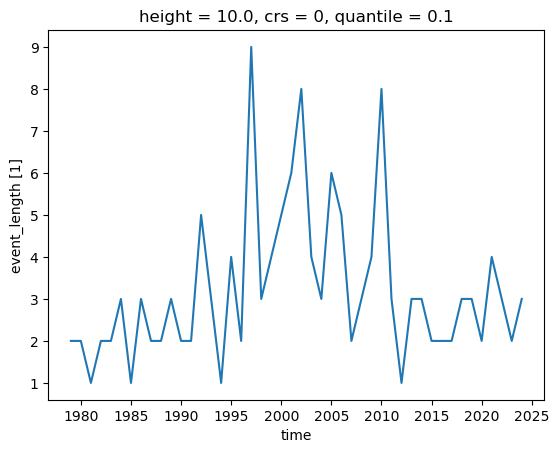

In [63]:
drought_events_new["event_length"].resample(time="1YS").max().plot()

#### Option 2

Pros
- Don't need to swap dimensions to find annual max

Cons
- Doesn't retain date of each drought (maybe not a problem as we know they're all in MJJ)
- Requires continuous time series (cannot drop months - does this add compute?)

In [64]:
ws_mjj = ws["wss"].where(ws["wss"].time.dt.month.isin([5, 6, 7]), drop=False) # Note no drop

In [65]:
drought_events = xclim.indices.generic.spell_length(
    ws_mjj,
    str(drought_thresh.values)+" m/s", # Have to compute drought threshold
    freq="1YS",
    reducer="max",
    op="<"
)

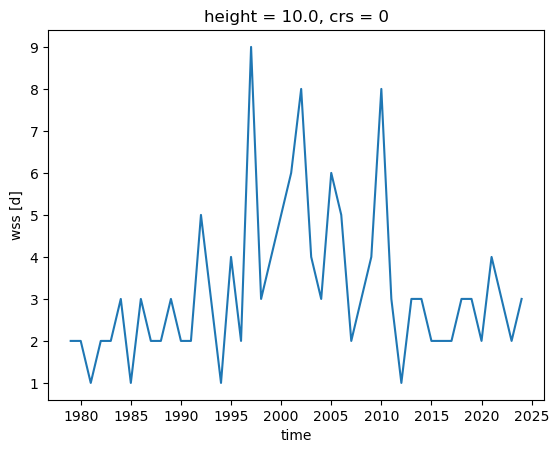

In [66]:
drought_events.plot()